In [ ]:
!pip -q install transformers peft accelerate

import os, math, random, copy
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
from google.colab import drive

drive.mount("/content/drive")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

ROOT = "/content/drive/My Drive/Lora Exp"
MODEL_PATH = f"{ROOT}/Models/gpt-neo-125m"
DATA1_DIR  = f"{ROOT}/Data1"
DATA_DIR   = f"{ROOT}/Data"
SAVE_ROOT  = f"{ROOT}/Unlearned_models"
os.makedirs(DATA1_DIR, exist_ok=True)
os.makedirs(SAVE_ROOT, exist_ok=True)

# Choose retain corpus file (will be truncated to a fixed token budget below)
RETAIN_PATH = f"{DATA_DIR}/roy.txt"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda


## **Tokenizer and Data**

In [ ]:
PREFIX_PATH = f"{DATA1_DIR}/train_prefix.npy"
SUFFIX_PATH = f"{DATA1_DIR}/train_suffix.npy"

!wget -O "{PREFIX_PATH}" "https://github.com/ethz-spylab/lm-extraction-benchmark-data/raw/main/datasets/train_prefix.npy"
!wget -O "{SUFFIX_PATH}" "https://github.com/ethz-spylab/lm-extraction-benchmark-data/raw/main/datasets/train_suffix.npy"


--2026-01-07 02:18:41--  https://github.com/ethz-spylab/lm-extraction-benchmark-data/raw/main/datasets/train_prefix.npy
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ethz-spylab/lm-extraction-benchmark-data/main/datasets/train_prefix.npy [following]
--2026-01-07 02:18:41--  https://raw.githubusercontent.com/ethz-spylab/lm-extraction-benchmark-data/main/datasets/train_prefix.npy
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1500128 (1.4M) [application/octet-stream]
Saving to: ‘/content/drive/My Drive/Lora Exp/Data1/train_prefix.npy’

/content/drive/My D 100%[===================>]   1.43M  --.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device)
base_model.eval()
print("Loaded base model + tokenizer")


Loaded base model + tokenizer


In [ ]:
prefixes = np.load(PREFIX_PATH, allow_pickle=True)  # (15000, 50)
suffixes = np.load(SUFFIX_PATH, allow_pickle=True)  # (15000, 50)
assert prefixes.shape == (15000, 50) and suffixes.shape == (15000, 50)

NUM_SEQS = 200
TOKENS_PER_SEQ = 200

idx = list(range(len(prefixes)))
random.Random(SEED).shuffle(idx)

forget_lines = []
forget_ids_200 = []  # keep token-exact IDs for eval if you want

for k in range(NUM_SEQS):
    i1 = idx[2*k]
    i2 = idx[2*k + 1]

    ids200 = (
        list(map(int, prefixes[i1])) + list(map(int, suffixes[i1])) +
        list(map(int, prefixes[i2])) + list(map(int, suffixes[i2]))
    )
    assert len(ids200) == TOKENS_PER_SEQ
    forget_ids_200.append(ids200)

    txt = tokenizer.decode(ids200).replace("\n", " ").replace("\r", " ").strip()
    forget_lines.append(txt)

FORGET_PATH = f"{DATA1_DIR}/tdec_forget_{NUM_SEQS}x{TOKENS_PER_SEQ}.txt"
with open(FORGET_PATH, "w", encoding="utf-8") as f:
    for line in forget_lines:
        f.write(line + "\n")

print("Saved forget:", FORGET_PATH, "lines:", len(forget_lines))


Saved forget: /content/drive/My Drive/Lora Exp/Data1/tdec_forget_200x200.txt lines: 200


In [ ]:
def read_text(path):
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

retain_full_text = read_text(RETAIN_PATH)

RETAIN_EVAL_TOKENS = 50_000
retain_ids_full = tokenizer(retain_full_text, return_tensors="pt", truncation=False).input_ids[0]
retain_ids_eval = retain_ids_full[:RETAIN_EVAL_TOKENS].to(device)
retain_eval_text = tokenizer.decode(retain_ids_eval)

RETAIN_50K_PATH = f"{DATA1_DIR}/retain_{RETAIN_EVAL_TOKENS}_tokens.txt"
with open(RETAIN_50K_PATH, "w", encoding="utf-8") as f:
    f.write(retain_eval_text)

print("Saved retain 50k:", RETAIN_50K_PATH, "tokens:", retain_ids_eval.numel())


Token indices sequence length is longer than the specified maximum sequence length for this model (151128 > 2048). Running this sequence through the model will result in indexing errors


Saved retain 50k: /content/drive/My Drive/Lora Exp/Data1/retain_50000_tokens.txt tokens: 50000


## **PPL Function**

In [ ]:
PPL_MAX_LEN = 512
PPL_STRIDE  = 256

def ppl(model, input_ids_1d, max_len=PPL_MAX_LEN, stride=PPL_STRIDE):
    """
    Strided sliding-window perplexity for fixed-length causal LMs.
    Keep max_len/stride fixed across ALL baselines and experiments. [web:32]
    """
    model.eval()
    seq_len = input_ids_1d.size(0)
    total_nll, total_pred = 0.0, 0

    with torch.no_grad():
        for start in range(0, seq_len - 1, stride):
            end = min(start + max_len, seq_len)
            chunk = input_ids_1d[start:end].unsqueeze(0).to(device)
            if chunk.size(1) < 2:
                break
            out = model(input_ids=chunk, labels=chunk)
            pred = chunk.size(1) - 1
            total_nll += out.loss.item() * pred
            total_pred += pred
            if end == seq_len:
                break

    return math.exp(total_nll / total_pred)


## **Baseline PPL**

In [ ]:
forget_eval_ids = tokenizer("\n".join(forget_lines), return_tensors="pt", truncation=False).input_ids[0].to(device)
retain_eval_ids = tokenizer(retain_eval_text, return_tensors="pt", truncation=False).input_ids[0].to(device)

print("forget eval tokens:", forget_eval_ids.numel())
print("retain eval tokens:", retain_eval_ids.numel())

forget eval tokens: 38951
retain eval tokens: 50000


In [ ]:


BASE_FORGET = ppl(base_model, forget_eval_ids)
BASE_RETAIN = ppl(base_model, retain_eval_ids)

print("BASE_FORGET:", BASE_FORGET)
print("BASE_RETAIN:", BASE_RETAIN)


BASE_FORGET: 11.77557685978259
BASE_RETAIN: 38.02937180100788


## **Training Batches and LoRA for unlearning**

In [ ]:
TRAIN_SEQ_LEN = 200
BATCH_SIZE = 4

def tokenize_fixed(lines, max_len=TRAIN_SEQ_LEN):
    enc = tokenizer(lines, padding="max_length", truncation=True, max_length=max_len, return_tensors="pt")
    return enc["input_ids"], enc["attention_mask"]

# Forget training set
forget_train_ids, forget_train_mask = tokenize_fixed(forget_lines)

# Retain training set from the SAME retain_eval_text (not full Byron!)
retain_ids_full_train = tokenizer(retain_eval_text, return_tensors="pt", truncation=False).input_ids[0]
retain_chunks = []
for i in range(0, len(retain_ids_full_train), TRAIN_SEQ_LEN):
    chunk = retain_ids_full_train[i:i+TRAIN_SEQ_LEN]
    if chunk.numel() < 50:
        continue
    if chunk.numel() < TRAIN_SEQ_LEN:
        chunk = F.pad(chunk, (0, TRAIN_SEQ_LEN - chunk.numel()), value=tokenizer.pad_token_id)
    retain_chunks.append(chunk)

retain_train_ids = torch.stack(retain_chunks)
retain_train_mask = (retain_train_ids != tokenizer.pad_token_id).long()

print("forget train:", forget_train_ids.shape)
print("retain train:", retain_train_ids.shape)


forget train: torch.Size([200, 200])
retain train: torch.Size([250, 200])


In [ ]:
class Iterator:
    def __init__(self, ids, mask, bs=BATCH_SIZE, seed=SEED):
        self.ids = ids
        self.mask = mask
        self.bs = bs
        self.gen = torch.Generator().manual_seed(seed)
        self.idx = torch.randperm(len(ids), generator=self.gen)
        self.pos = 0

    def batch(self):
        if self.pos + self.bs > len(self.idx):
            self.idx = torch.randperm(len(self.ids), generator=self.gen)
            self.pos = 0
        b = self.idx[self.pos:self.pos+self.bs]
        self.pos += self.bs
        return self.ids[b].to(device), self.mask[b].to(device)


## **Defining Unlearning Methods, Loss and LoRA**

In [ ]:
def make_lora(rank, alpha=None, dropout=0.05):
    if alpha is None:
        alpha = 2 * rank
    m = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device)
    cfg = LoraConfig(
        r=rank, lora_alpha=alpha, lora_dropout=dropout,
        target_modules=["q_proj", "v_proj"],
        bias="none", task_type="CAUSAL_LM"
    )
    m = get_peft_model(m, cfg)
    m.print_trainable_parameters()
    return m

def ce_loss(model, input_ids, attn_mask):
    labels = input_ids.clone()
    labels[attn_mask == 0] = -100
    return model(input_ids=input_ids, attention_mask=attn_mask, labels=labels).loss

def run_GA(model, forget_iter, lr=1e-5, steps=400, clip=1.0):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    for step in range(steps):
        x_f, m_f = forget_iter.batch()
        loss_f = ce_loss(model, x_f, m_f)
        total = -loss_f
        opt.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        if step % 100 == 0:
            print(f"[GA] {step}/{steps} forget_CE={loss_f.item():.4f}")
    model.eval()

def run_GD(model, forget_iter, retain_iter, lr=2e-5, steps=200, lambda_retain=4.0, clip=1.0):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    for step in range(steps):
        x_f, m_f = forget_iter.batch()
        x_r, m_r = retain_iter.batch()
        loss_f = ce_loss(model, x_f, m_f)
        loss_r = ce_loss(model, x_r, m_r)
        total = -loss_f + lambda_retain * loss_r
        opt.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()
        if step % 100 == 0:
            print(f"[GD] {step}/{steps} forget={loss_f.item():.4f} retain={loss_r.item():.4f}")
    model.eval()

def run_KL(model, ref_model, forget_iter, retain_iter, lr=1e-5, steps=400, beta=5.0, clip=1.0):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    model.train()
    ref_model.eval()
    for step in range(steps):
        x_f, m_f = forget_iter.batch()
        x_r, m_r = retain_iter.batch()

        loss_f = ce_loss(model, x_f, m_f)

        logits_new = model(input_ids=x_r, attention_mask=m_r).logits
        with torch.no_grad():
            logits_ref = ref_model(input_ids=x_r, attention_mask=m_r).logits

        log_p_new = F.log_softmax(logits_new, dim=-1)
        p_ref = F.softmax(logits_ref, dim=-1)
        kl_tok = F.kl_div(log_p_new, p_ref, reduction="none").sum(-1)  # [B,T]
        kl = (kl_tok * m_r.float()).sum() / m_r.float().sum().clamp_min(1.0)


        total = -loss_f + beta * kl
        opt.zero_grad()
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        opt.step()

        if step % 100 == 0:
            print(f"[KL] {step}/{steps} forget={loss_f.item():.4f} kl={kl.item():.4f}")
    model.eval()


## **Unlearning EXP**

## **GA**

In [ ]:
RANK = 2
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GA  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GA_rank{RANK}_seed{SEED}"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[GA] 0/300 forget_CE=2.1389
[GA] 100/300 forget_CE=2.2519
[GA] 200/300 forget_CE=2.6556
GA  Forget: 11.77557685978259 -> 11.973602673020842  | Retain: 38.02937180100788 -> 38.04242222116006
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GA_rank2_seed42


In [ ]:
RANK = 4
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GA  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GA_rank{RANK}_seed{SEED}"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[GA] 0/300 forget_CE=2.1389
[GA] 100/300 forget_CE=2.2567
[GA] 200/300 forget_CE=2.6663
GA  Forget: 11.77557685978259 -> 12.311503933529535  | Retain: 38.02937180100788 -> 38.07253822537209
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GA_rank4_seed42


In [ ]:
RANK = 8
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GA  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GA_rank{RANK}_seed{SEED}"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[GA] 0/300 forget_CE=2.1389
[GA] 100/300 forget_CE=2.2616
[GA] 200/300 forget_CE=2.6874
GA  Forget: 11.77557685978259 -> 12.899103667998174  | Retain: 38.02937180100788 -> 38.25579542290997
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GA_rank8_seed42


In [ ]:
RANK = 16
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GA  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GA_rank{RANK}_seed{SEED}"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[GA] 0/300 forget_CE=2.1389
[GA] 100/300 forget_CE=2.2797
[GA] 200/300 forget_CE=2.7231
GA  Forget: 11.77557685978259 -> 16.423502206787823  | Retain: 38.02937180100788 -> 41.247717728284194
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GA_rank16_seed42


In [ ]:
RANK = 32
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GA  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GA_rank{RANK}_seed{SEED}"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[GA] 0/300 forget_CE=2.1389
[GA] 100/300 forget_CE=2.3212
[GA] 200/300 forget_CE=2.8855
GA  Forget: 11.77557685978259 -> 33.23712674723548  | Retain: 38.02937180100788 -> 53.24279216086109
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GA_rank32_seed42


## **GD**

In [ ]:
RANK = 2
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)
run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GD  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GD_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[GD] 0/150 forget=2.1389 retain=4.0061
[GD] 100/150 forget=2.2643 retain=3.7749
GD  Forget: 11.77557685978259 -> 12.058584193261431  | Retain: 38.02937180100788 -> 36.94786913460459
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GD_rank2_seed42_lr5e-5_steps150_lambda5


In [ ]:
RANK = 4
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)
run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GD  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GD_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[GD] 0/150 forget=2.1389 retain=4.0061
[GD] 100/150 forget=2.2904 retain=3.7556
GD  Forget: 11.77557685978259 -> 12.765089248618926  | Retain: 38.02937180100788 -> 36.452171807077065
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GD_rank4_seed42_lr5e-5_steps150_lambda5


In [ ]:
RANK = 8
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)
run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GD  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GD_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[GD] 0/150 forget=2.1389 retain=4.0061
[GD] 100/150 forget=2.3353 retain=3.7252
GD  Forget: 11.77557685978259 -> 14.439385870352623  | Retain: 38.02937180100788 -> 35.95675926170455
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GD_rank8_seed42_lr5e-5_steps150_lambda5


In [ ]:
RANK = 16
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)
run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GD  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GD_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[GD] 0/150 forget=2.1389 retain=4.0061
[GD] 100/150 forget=2.5057 retain=3.6884
GD  Forget: 11.77557685978259 -> 26.527283903468632  | Retain: 38.02937180100788 -> 35.8162892339638
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GD_rank16_seed42_lr5e-5_steps150_lambda5


In [ ]:
RANK = 32
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)
run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("GD  Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/GD_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[GD] 0/150 forget=2.1389 retain=4.0061
[GD] 100/150 forget=2.9517 retain=3.6761
GD  Forget: 11.77557685978259 -> 83.79131003099101  | Retain: 38.02937180100788 -> 36.2106241575384
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/GD_rank32_seed42_lr5e-5_steps150_lambda5


## **KL**

In [ ]:
RANK = 2

# base reference (no LoRA)
ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

# trainable model is LoRA-wrapped
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

run_KL(model, ref_model, forget_iter, retain_iter,
       lr=1e-5, steps=400, beta=5.0, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("KL(baseRef) Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/KL_baseRef_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5_clip1"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[KL] 0/400 forget=2.1389 kl=-0.0000
[KL] 100/400 forget=2.2528 kl=0.0000
[KL] 200/400 forget=2.6563 kl=0.0001
[KL] 300/400 forget=2.4281 kl=0.0002
KL(baseRef) Forget: 11.77557685978259 -> 12.119681497923626  | Retain: 38.02937180100788 -> 38.04743647827837
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/KL_baseRef_rank2_seed42_lr1e-5_steps400_beta5_clip1


In [ ]:
RANK = 4

# base reference (no LoRA)
ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

# trainable model is LoRA-wrapped
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

run_KL(model, ref_model, forget_iter, retain_iter,
       lr=1e-5, steps=400, beta=5.0, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("KL(baseRef) Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/KL_baseRef_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5_clip1"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[KL] 0/400 forget=2.1389 kl=-0.0000
[KL] 100/400 forget=2.2544 kl=0.0000
[KL] 200/400 forget=2.6639 kl=0.0001
[KL] 300/400 forget=2.4412 kl=0.0004
KL(baseRef) Forget: 11.77557685978259 -> 12.456758685984939  | Retain: 38.02937180100788 -> 38.091056169341535
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/KL_baseRef_rank4_seed42_lr1e-5_steps400_beta5_clip1


In [ ]:
RANK = 8

# base reference (no LoRA)
ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

# trainable model is LoRA-wrapped
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

run_KL(model, ref_model, forget_iter, retain_iter,
       lr=1e-5, steps=400, beta=5.0, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("KL(baseRef) Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/KL_baseRef_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5_clip1"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[KL] 0/400 forget=2.1389 kl=-0.0000
[KL] 100/400 forget=2.2641 kl=0.0001
[KL] 200/400 forget=2.6878 kl=0.0008
[KL] 300/400 forget=2.4839 kl=0.0021
KL(baseRef) Forget: 11.77557685978259 -> 13.782206030957543  | Retain: 38.02937180100788 -> 38.183169611614424
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/KL_baseRef_rank8_seed42_lr1e-5_steps400_beta5_clip1


In [ ]:
RANK = 16

# base reference (no LoRA)
ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

# trainable model is LoRA-wrapped
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

run_KL(model, ref_model, forget_iter, retain_iter,
       lr=1e-5, steps=400, beta=5.0, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("KL(baseRef) Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/KL_baseRef_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5_clip1"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[KL] 0/400 forget=2.1389 kl=-0.0000
[KL] 100/400 forget=2.2759 kl=0.0003
[KL] 200/400 forget=2.7244 kl=0.0022
[KL] 300/400 forget=2.5509 kl=0.0056
KL(baseRef) Forget: 11.77557685978259 -> 17.183637380666234  | Retain: 38.02937180100788 -> 38.39741106947992
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/KL_baseRef_rank16_seed42_lr1e-5_steps400_beta5_clip1


In [ ]:
RANK = 32

# base reference (no LoRA)
ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

# trainable model is LoRA-wrapped
model = make_lora(RANK)

forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

run_KL(model, ref_model, forget_iter, retain_iter,
       lr=1e-5, steps=400, beta=5.0, clip=1.0)

merged = model.merge_and_unload()
pF = ppl(merged, forget_eval_ids)
pR = ppl(merged, retain_eval_ids)

print("KL(baseRef) Forget:", BASE_FORGET, "->", pF, " | Retain:", BASE_RETAIN, "->", pR)

save_dir = f"{SAVE_ROOT}/KL_baseRef_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5_clip1"
merged.save_pretrained(save_dir)
print("saved:", save_dir)


trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[KL] 0/400 forget=2.1389 kl=-0.0000
[KL] 100/400 forget=2.3125 kl=0.0012
[KL] 200/400 forget=2.8087 kl=0.0076
[KL] 300/400 forget=2.6947 kl=0.0169
KL(baseRef) Forget: 11.77557685978259 -> 33.00390781732539  | Retain: 38.02937180100788 -> 38.7987944890893
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/KL_baseRef_rank32_seed42_lr1e-5_steps400_beta5_clip1


## **Plot**

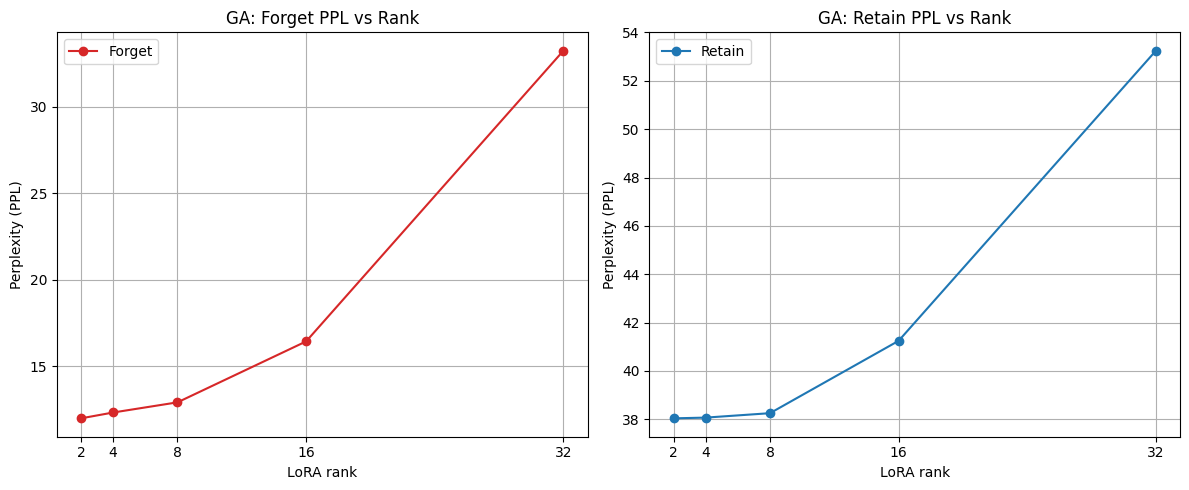

Saved: /content/drive/My Drive/Lora Exp/results/GA_rank_vs_ppl_side_by_side.png


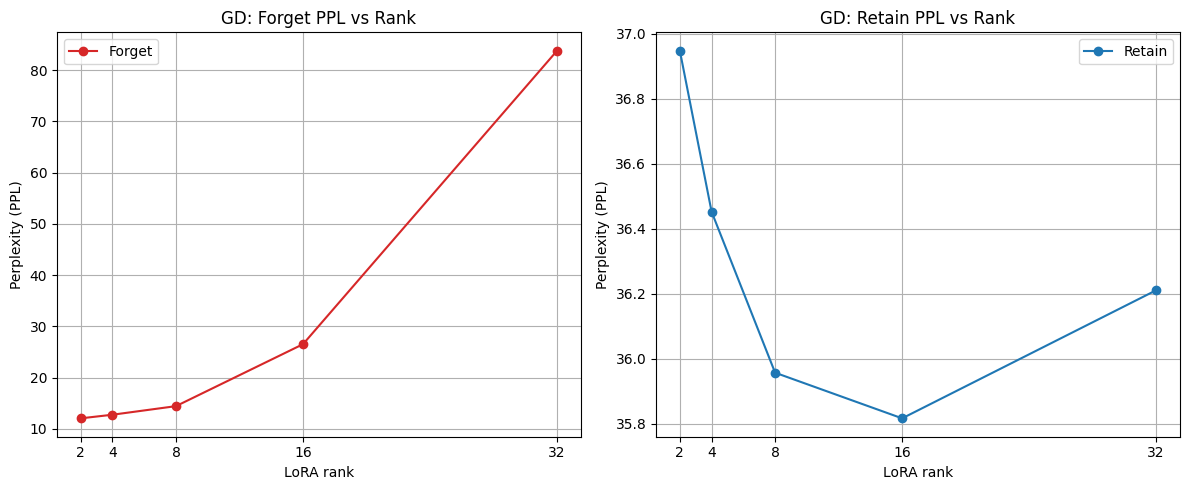

Saved: /content/drive/My Drive/Lora Exp/results/GD_rank_vs_ppl_side_by_side.png


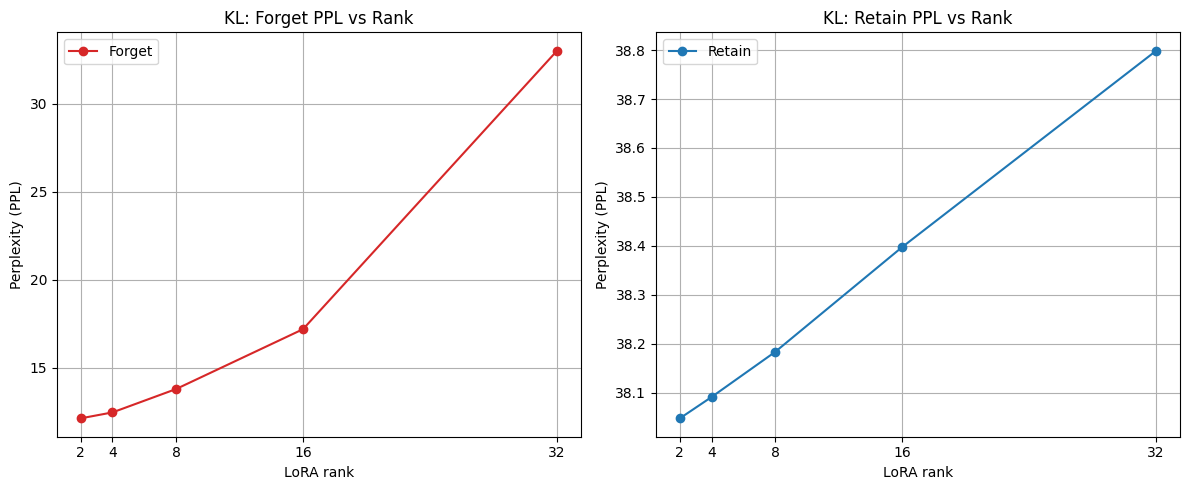

Saved: /content/drive/My Drive/Lora Exp/results/KL_rank_vs_ppl_side_by_side.png


In [ ]:
import os
import matplotlib.pyplot as plt

RESULTS_DIR = f"{ROOT}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def plot_side_by_side_rank_on_x(method, ranks, forget_ppl, retain_ppl):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))  # [web:425]

    # Left: Forget (x=Rank, y=PPL)
    ax1.plot(ranks, forget_ppl, marker="o", color="tab:red", label="Forget")
    ax1.set_title(f"{method}: Forget PPL vs Rank")
    ax1.set_xlabel("LoRA rank")
    ax1.set_ylabel("Perplexity (PPL)")
    ax1.set_xticks(ranks)
    ax1.grid(True)
    ax1.legend()

    # Right: Retain (x=Rank, y=PPL)
    ax2.plot(ranks, retain_ppl, marker="o", color="tab:blue", label="Retain")
    ax2.set_title(f"{method}: Retain PPL vs Rank")
    ax2.set_xlabel("LoRA rank")
    ax2.set_ylabel("Perplexity (PPL)")
    ax2.set_xticks(ranks)
    ax2.grid(True)
    ax2.legend()

    fig.tight_layout()
    out_path = os.path.join(RESULTS_DIR, f"{method}_rank_vs_ppl_side_by_side.png")
    plt.savefig(out_path, dpi=200)  # [web:419]
    plt.show()
    print("Saved:", out_path)

RANKS = [2, 4, 8, 16, 32]

# GA
GA_forget = [11.973602673020842, 12.311503933529535, 12.899103667998174, 16.423502206787823, 33.23712674723548]
GA_retain = [38.04242222116006, 38.07253822537209, 38.25579542290997, 41.247717728284194, 53.24279216086109]
plot_side_by_side_rank_on_x("GA", RANKS, GA_forget, GA_retain)

# GD
GD_forget = [12.058584193261431, 12.765089248618926, 14.439385870352623, 26.527283903468632, 83.79131003099101]
GD_retain = [36.94786913460459, 36.452171807077065, 35.95675926170455, 35.8162892339638, 36.2106241575384]
plot_side_by_side_rank_on_x("GD", RANKS, GD_forget, GD_retain)

# KL
KL_forget = [12.119681497923626, 12.456758685984939, 13.782206030957543, 17.183637380666234, 33.00390781732539]
KL_retain = [38.04743647827837, 38.091056169341535, 38.183169611614424, 38.39741106947992, 38.7987944890893]
plot_side_by_side_rank_on_x("KL", RANKS, KL_forget, KL_retain)


In [ ]:
# Force install and restart
!pip uninstall -y bitsandbytes
!pip install bitsandbytes
import os
os.kill(os.getpid(), 9)  # Force restart


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.0 MB/s eta 0:00:00


In [ ]:
# ============================================================
# QLORA (BITSANDBYTES)
# ============================================================

from transformers import BitsAndBytesConfig, AutoModelForCausalLM
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

def make_qlora(rank=8, bits=4, alpha=None, dropout=0.05):

    if alpha is None:
        alpha = 2 * rank

    if bits == 4:
        print("🔧 4-bit: bitsandbytes NF4 quantization")
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
        )
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_PATH, quantization_config=bnb_config, device_map="auto"
        )
        model = prepare_model_for_kbit_training(model)

    elif bits == 8:
        print("🔧 8-bit: bitsandbytes INT8 quantization")
        bnb_config = BitsAndBytesConfig(load_in_8bit=True)
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_PATH, quantization_config=bnb_config, device_map="auto"
        )
        model = prepare_model_for_kbit_training(model)

    elif bits == 16:
        print("ℹ️ 16-bit: FP16 (no quantization)")
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_PATH, torch_dtype=torch.float16, device_map="auto"
        )

    elif bits == 32:
        print("ℹ️ 32-bit: FP32 (no quantization)")
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_PATH, torch_dtype=torch.float32
        ).to(device)

    else:
        raise ValueError(f"bits must be in [4,8,16,32], got {bits}")

    lora_config = LoraConfig(
        r=rank, lora_alpha=alpha, lora_dropout=dropout,
        target_modules=["q_proj", "v_proj"],
        bias="none", task_type="CAUSAL_LM"
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model

print("✓ make_qlora() defined")


✓ make_qlora() defined


## **GD**

## **Rank=2**

In [ ]:
# ============================================================
# QLORA  Setup (no 2-bit)
# ============================================================

RANK = 2
BITS_LIST = [4, 8, 16, 32]  # Skip 2-bit (not supported)

print(f"Ready for QLoRA: rank={RANK}, bits={BITS_LIST}")



Ready for QLoRA: rank=2, bits=[4, 8, 16, 32]


In [ ]:
# ============================================================
# QLORA: Run GD
# ============================================================

qlora_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GD: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GD_bits{BITS}_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GD complete")
for b, pf, pr in qlora_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GD: bits=4, rank=2
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[GD] 0/150 forget=2.9372 retain=4.3418
[GD] 100/150 forget=2.8276 retain=4.1043
QLoRA bits=4 | Forget: 11.78->21.51 | Retain: 38.03->55.48
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits4_rank2_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=8, rank=2
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[GD] 0/150 forget=2.2521 retain=4.0753
[GD] 100/150 forget=2.3836 retain=3.8324
QLoRA bits=8 | Forget: 11.78->13.01 | Retain: 38.03->40.42
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits8_rank2_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=16, rank=2
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[GD] 0/150 forget=2.1387 retain=4.0078
[GD] 100/150 forget=2.2676 retain=3.7754
QLoRA bits

## **Rank=4**

In [ ]:
# ============================================================
# QLORA  Setup (no 2-bit)
# ============================================================

RANK = 4
BITS_LIST = [4, 8, 16, 32]  # Skip 2-bit (not supported)

print(f"Ready for QLoRA: rank={RANK}, bits={BITS_LIST}")



Ready for QLoRA: rank=4, bits=[4, 8, 16, 32]


In [ ]:
# ============================================================
# QLORA: Run GD
# ============================================================

qlora_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GD: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GD_bits{BITS}_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GD complete")
for b, pf, pr in qlora_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GD: bits=4, rank=4
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[GD] 0/150 forget=2.9372 retain=4.3418
[GD] 100/150 forget=2.8461 retain=4.0620
QLoRA bits=4 | Forget: 11.78->21.51 | Retain: 38.03->55.45
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits4_rank4_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=8, rank=4
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[GD] 0/150 forget=2.2521 retain=4.0753
[GD] 100/150 forget=2.3749 retain=3.8194
QLoRA bits=8 | Forget: 11.78->12.93 | Retain: 38.03->40.44
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits8_rank4_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=16, rank=4
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[GD] 0/150 forget=2.1387 retain=4.0078
[GD] 100/150 forget=2.2871 retain=3.7559
QLoRA b

## **Rank=8**

In [ ]:
# ============================================================
# QLORA  Setup (no 2-bit)
# ============================================================

RANK = 8
BITS_LIST = [4, 8, 16, 32]  # Skip 2-bit (not supported)

print(f"Ready for QLoRA: rank={RANK}, bits={BITS_LIST}")



Ready for QLoRA: rank=8, bits=[4, 8, 16, 32]


In [ ]:
# ============================================================
# QLORA: Run GD
# ============================================================

qlora_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GD: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GD_bits{BITS}_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GD complete")
for b, pf, pr in qlora_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GD: bits=4, rank=8
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[GD] 0/150 forget=2.9372 retain=4.3418
[GD] 100/150 forget=2.9240 retain=4.0021
QLoRA bits=4 | Forget: 11.78->21.51 | Retain: 38.03->55.45
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits4_rank8_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=8, rank=8
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[GD] 0/150 forget=2.2521 retain=4.0753
[GD] 100/150 forget=2.4250 retain=3.7937
QLoRA bits=8 | Forget: 11.78->13.01 | Retain: 38.03->40.45
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits8_rank8_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=16, rank=8
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[GD] 0/150 forget=2.1387 retain=4.0078
[GD] 100/150 forget=2.3301 retain=3.7246
QLoRA b

## **Rank=16**

In [ ]:
# ============================================================
# QLORA  Setup (no 2-bit)
# ============================================================

RANK = 16
BITS_LIST = [4, 8, 16, 32]  # Skip 2-bit (not supported)

print(f"Ready for QLoRA: rank={RANK}, bits={BITS_LIST}")



Ready for QLoRA: rank=16, bits=[4, 8, 16, 32]


In [ ]:
# ============================================================
# QLORA: Run GD
# ============================================================

qlora_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GD: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GD_bits{BITS}_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GD complete")
for b, pf, pr in qlora_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GD: bits=4, rank=16
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[GD] 0/150 forget=2.9372 retain=4.3418
[GD] 100/150 forget=3.0939 retain=3.9510
QLoRA bits=4 | Forget: 11.78->21.53 | Retain: 38.03->55.40
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits4_rank16_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=8, rank=16
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[GD] 0/150 forget=2.2521 retain=4.0753
[GD] 100/150 forget=2.5645 retain=3.7633
QLoRA bits=8 | Forget: 11.78->15.90 | Retain: 38.03->39.16
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits8_rank16_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=16, rank=16
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[GD] 0/150 forget=2.1387 retain=4.0078
[GD] 100/150 forget=2.4785 retain=3.6914
QL

## **Rank=32**

In [ ]:
# ============================================================
# QLORA  Setup (no 2-bit)
# ============================================================

RANK = 32
BITS_LIST = [4, 8, 16, 32]  # Skip 2-bit (not supported)

print(f"Ready for QLoRA: rank={RANK}, bits={BITS_LIST}")



Ready for QLoRA: rank=32, bits=[4, 8, 16, 32]


In [ ]:
# ============================================================
# QLORA: Run GD
# ============================================================

qlora_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GD: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_GD(model, forget_iter, retain_iter, lr=5e-5, steps=150, lambda_retain=5, clip=2.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GD_bits{BITS}_rank{RANK}_seed{SEED}_lr5e-5_steps150_lambda5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GD complete")
for b, pf, pr in qlora_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GD: bits=4, rank=32
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[GD] 0/150 forget=2.9372 retain=4.3418
[GD] 100/150 forget=3.4384 retain=3.9117
QLoRA bits=4 | Forget: 11.78->21.54 | Retain: 38.03->55.30
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits4_rank32_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=8, rank=32
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[GD] 0/150 forget=2.2521 retain=4.0753
[GD] 100/150 forget=2.9867 retain=3.7671
QLoRA bits=8 | Forget: 11.78->38.31 | Retain: 38.03->38.18
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GD_bits8_rank32_seed42_lr5e-5_steps150_lambda5

QLoRA-GD: bits=16, rank=32
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[GD] 0/150 forget=2.1387 retain=4.0078
[GD] 100/150 forget=2.9746 retain=3.6

# **GA**

## **Rank=2**

In [ ]:
RANK = 2
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-GA: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-GA: rank=2, bits=[4, 8, 16, 32]


In [ ]:
qlora_ga_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GA: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)

    run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-GA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GA_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps300"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_ga_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GA complete")
for b, pf, pr in qlora_ga_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GA: bits=4, rank=2
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[GA] 0/300 forget_CE=2.9372
[GA] 100/300 forget_CE=2.8269
[GA] 200/300 forget_CE=3.1888
QLoRA-GA bits=4 | Forget: 11.78->21.51 | Retain: 38.03->55.49
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits4_rank2_seed42_lr1e-5_steps300

QLoRA-GA: bits=8, rank=2
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[GA] 0/300 forget_CE=2.2521
[GA] 100/300 forget_CE=2.3733
[GA] 200/300 forget_CE=2.7558
QLoRA-GA bits=8 | Forget: 11.78->12.96 | Retain: 38.03->40.41
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits8_rank2_seed42_lr1e-5_steps300

QLoRA-GA: bits=16, rank=2
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[GA] 0/300 forget_CE=2.1387
[GA] 100/300 forget_CE=2.2520
[GA] 200/300 forget_CE=2.6

## **Rank=4**

In [ ]:
RANK = 4
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-GA: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-GA: rank=4, bits=[4, 8, 16, 32]


In [ ]:
qlora_ga_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GA: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)

    run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-GA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GA_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps300"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_ga_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GA complete")
for b, pf, pr in qlora_ga_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GA: bits=4, rank=4
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[GA] 0/300 forget_CE=2.9372
[GA] 100/300 forget_CE=2.8354
[GA] 200/300 forget_CE=3.2235
QLoRA-GA bits=4 | Forget: 11.78->21.52 | Retain: 38.03->55.51
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits4_rank4_seed42_lr1e-5_steps300

QLoRA-GA: bits=8, rank=4
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[GA] 0/300 forget_CE=2.2521
[GA] 100/300 forget_CE=2.3516
[GA] 200/300 forget_CE=2.7896
QLoRA-GA bits=8 | Forget: 11.78->12.97 | Retain: 38.03->40.49
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits8_rank4_seed42_lr1e-5_steps300

QLoRA-GA: bits=16, rank=4
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[GA] 0/300 forget_CE=2.1387
[GA] 100/300 forget_CE=2.2559
[GA] 200/300 forget_CE=

## **Rank=8**

In [ ]:
RANK = 8
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-GA: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-GA: rank=8, bits=[4, 8, 16, 32]


In [ ]:
qlora_ga_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GA: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)

    run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-GA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GA_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps300"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_ga_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GA complete")
for b, pf, pr in qlora_ga_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GA: bits=4, rank=8
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[GA] 0/300 forget_CE=2.9372
[GA] 100/300 forget_CE=2.8571
[GA] 200/300 forget_CE=3.3105
QLoRA-GA bits=4 | Forget: 11.78->21.53 | Retain: 38.03->55.52
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits4_rank8_seed42_lr1e-5_steps300

QLoRA-GA: bits=8, rank=8
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[GA] 0/300 forget_CE=2.2521
[GA] 100/300 forget_CE=2.3801
[GA] 200/300 forget_CE=2.7680
QLoRA-GA bits=8 | Forget: 11.78->12.98 | Retain: 38.03->40.45
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits8_rank8_seed42_lr1e-5_steps300

QLoRA-GA: bits=16, rank=8
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[GA] 0/300 forget_CE=2.1387
[GA] 100/300 forget_CE=2.2656
[GA] 200/300 forget_CE=

## **Rank=16**

In [ ]:
RANK = 16
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-GA: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-GA: rank=16, bits=[4, 8, 16, 32]


In [ ]:
qlora_ga_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GA: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)

    run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-GA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GA_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps300"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_ga_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GA complete")
for b, pf, pr in qlora_ga_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GA: bits=4, rank=16
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[GA] 0/300 forget_CE=2.9372
[GA] 100/300 forget_CE=2.9031
[GA] 200/300 forget_CE=3.4724
QLoRA-GA bits=4 | Forget: 11.78->21.55 | Retain: 38.03->55.53
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits4_rank16_seed42_lr1e-5_steps300

QLoRA-GA: bits=8, rank=16
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[GA] 0/300 forget_CE=2.2521
[GA] 100/300 forget_CE=2.3959
[GA] 200/300 forget_CE=2.8438
QLoRA-GA bits=8 | Forget: 11.78->13.00 | Retain: 38.03->40.45
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits8_rank16_seed42_lr1e-5_steps300

QLoRA-GA: bits=16, rank=16
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[GA] 0/300 forget_CE=2.1387
[GA] 100/300 forget_CE=2.2793
[GA] 200/300 forge

## **Rank=32**

In [ ]:
RANK = 32
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-GA: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-GA: rank=32, bits=[4, 8, 16, 32]


In [ ]:
qlora_ga_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-GA: bits={BITS}, rank={RANK}\n{'='*60}")

    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)

    run_GA(model, forget_iter, lr=1e-5, steps=300, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-GA bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_GA_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps300"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_ga_results.append((BITS, float(pF), float(pR)))

    del model, merged
    torch.cuda.empty_cache()

print("\n QLoRA-GA complete")
for b, pf, pr in qlora_ga_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-GA: bits=4, rank=32
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[GA] 0/300 forget_CE=2.9372
[GA] 100/300 forget_CE=3.0216
[GA] 200/300 forget_CE=3.8526
QLoRA-GA bits=4 | Forget: 11.78->21.57 | Retain: 38.03->55.55
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits4_rank32_seed42_lr1e-5_steps300

QLoRA-GA: bits=8, rank=32
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[GA] 0/300 forget_CE=2.2521
[GA] 100/300 forget_CE=2.4146
[GA] 200/300 forget_CE=3.0426
QLoRA-GA bits=8 | Forget: 11.78->13.42 | Retain: 38.03->40.57
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_GA_bits8_rank32_seed42_lr1e-5_steps300

QLoRA-GA: bits=16, rank=32
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 1,179,648 || all params: 126,378,240 || trainable%: 0.9334
[GA] 0/300 forget_CE=2.1387
[GA] 100/300 forget_CE=2.3086
[GA] 200/300

# **KL**

## **Rank=2**

In [ ]:
RANK = 2
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-KL: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-KL: rank=2, bits=[4, 8, 16, 32]


In [ ]:
qlora_kl_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-KL: bits={BITS}, rank={RANK}\n{'='*60}")

    # Reference model (base, no LoRA)
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

    # Trainable QLoRA model
    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_KL(model, ref_model, forget_iter, retain_iter, lr=1e-5, steps=400, beta=5.0, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-KL bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_KL_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_kl_results.append((BITS, float(pF), float(pR)))

    del model, merged, ref_model
    torch.cuda.empty_cache()

print("\n QLoRA-KL complete")
for b, pf, pr in qlora_kl_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-KL: bits=4, rank=2
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


[KL] 0/400 forget=2.9372 kl=0.4431
[KL] 100/400 forget=2.8188 kl=0.4318
[KL] 200/400 forget=3.1640 kl=0.4457
[KL] 300/400 forget=2.8885 kl=0.4012


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


QLoRA-KL bits=4 | Forget: 11.78->21.51 | Retain: 38.03->55.49
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits4_rank2_seed42_lr1e-5_steps400_beta5

QLoRA-KL: bits=8, rank=2
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589


...

[KL] 0/400 forget=2.2521 kl=0.0744
[KL] 100/400 forget=2.3682 kl=0.0762
[KL] 200/400 forget=2.7483 kl=0.0765
[KL] 300/400 forget=2.4939 kl=0.0739


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:110: UserWarning: Merge lora module to 8-bit linear may get different generations due to rounding errors.
  warnings.warn(


QLoRA-KL bits=8 | Forget: 11.78->13.00 | Retain: 38.03->40.43
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits8_rank2_seed42_lr1e-5_steps400_beta5

QLoRA-KL: bits=16, rank=2
ℹ️ 16-bit: FP16 (no quantization)


`torch_dtype` is deprecated! Use `dtype` instead!


trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[KL] 0/400 forget=2.1387 kl=0.0000
[KL] 100/400 forget=2.2520 kl=0.0001
[KL] 200/400 forget=2.6562 kl=0.0001
[KL] 300/400 forget=2.4277 kl=0.0003
QLoRA-KL bits=16 | Forget: 11.78->12.16 | Retain: 38.03->38.03
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits16_rank2_seed42_lr1e-5_steps400_beta5

QLoRA-KL: bits=32, rank=2
ℹ️ 32-bit: FP32 (no quantization)
trainable params: 73,728 || all params: 125,272,320 || trainable%: 0.0589
[KL] 0/400 forget=2.1389 kl=-0.0000
[KL] 100/400 forget=2.2537 kl=0.0000
[KL] 200/400 forget=2.6593 kl=0.0001
[KL] 300/400 forget=2.4311 kl=0.0002
QLoRA-KL bits=32 | Forget: 11.78->12.15 | Retain: 38.03->38.05
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits32_rank2_seed42_lr1e-5_steps400_beta5

 QLoRA-KL complete
  bits=4: forget=21.51, retain=55.49
  bits=8: forget=13.00, retain=40.43
  bits=16: forget=12.16, retain=38.03
  bits=32: forget=12.15,

## **Rank=4**

In [ ]:
RANK = 4
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-KL: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-KL: rank=4, bits=[4, 8, 16, 32]


In [ ]:
qlora_kl_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-KL: bits={BITS}, rank={RANK}\n{'='*60}")

    # Reference model (base, no LoRA)
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

    # Trainable QLoRA model
    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_KL(model, ref_model, forget_iter, retain_iter, lr=1e-5, steps=400, beta=5.0, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-KL bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_KL_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_kl_results.append((BITS, float(pF), float(pR)))

    del model, merged, ref_model
    torch.cuda.empty_cache()

print("\n QLoRA-KL complete")
for b, pf, pr in qlora_kl_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-KL: bits=4, rank=4
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[KL] 0/400 forget=2.9372 kl=0.4431
[KL] 100/400 forget=2.8200 kl=0.4281
[KL] 200/400 forget=3.1673 kl=0.4329
[KL] 300/400 forget=2.8933 kl=0.3851
QLoRA-KL bits=4 | Forget: 11.78->21.51 | Retain: 38.03->55.49
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits4_rank4_seed42_lr1e-5_steps400_beta5

QLoRA-KL: bits=8, rank=4
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 147,456 || all params: 125,346,048 || trainable%: 0.1176
[KL] 0/400 forget=2.2521 kl=0.0744
[KL] 100/400 forget=2.3566 kl=0.0778
[KL] 200/400 forget=2.7828 kl=0.0734
[KL] 300/400 forget=2.5141 kl=0.0690
QLoRA-KL bits=8 | Forget: 11.78->12.97 | Retain: 38.03->40.48
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits8_rank4_seed42_lr1e-5_steps400_beta5

QLoRA-KL: bits=16, rank=4
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 147,456 ||

## **Rank=8**

In [ ]:
RANK = 8
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-KL: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-KL: rank=8, bits=[4, 8, 16, 32]


In [ ]:
qlora_kl_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-KL: bits={BITS}, rank={RANK}\n{'='*60}")

    # Reference model (base, no LoRA)
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

    # Trainable QLoRA model
    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_KL(model, ref_model, forget_iter, retain_iter, lr=1e-5, steps=400, beta=5.0, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-KL bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_KL_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_kl_results.append((BITS, float(pF), float(pR)))

    del model, merged, ref_model
    torch.cuda.empty_cache()

print("\n QLoRA-KL complete")
for b, pf, pr in qlora_kl_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-KL: bits=4, rank=8
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[KL] 0/400 forget=2.9372 kl=0.4431
[KL] 100/400 forget=2.8198 kl=0.4150
[KL] 200/400 forget=3.1752 kl=0.4078
[KL] 300/400 forget=2.9041 kl=0.3585
QLoRA-KL bits=4 | Forget: 11.78->21.51 | Retain: 38.03->55.48
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits4_rank8_seed42_lr1e-5_steps400_beta5

QLoRA-KL: bits=8, rank=8
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 294,912 || all params: 125,493,504 || trainable%: 0.2350
[KL] 0/400 forget=2.2521 kl=0.0744
[KL] 100/400 forget=2.3697 kl=0.0775
[KL] 200/400 forget=2.7663 kl=0.0718
[KL] 300/400 forget=2.5584 kl=0.0733
QLoRA-KL bits=8 | Forget: 11.78->12.94 | Retain: 38.03->40.50
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits8_rank8_seed42_lr1e-5_steps400_beta5

QLoRA-KL: bits=16, rank=8
ℹ️ 16-bit: FP16 (no quantization)
trainable params: 294,912 ||

## **Rank=16**

In [ ]:
RANK = 16
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-KL: rank={RANK}, bits={BITS_LIST}")


 Ready for QLoRA-KL: rank=16, bits=[4, 8, 16, 32]


In [ ]:
qlora_kl_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-KL: bits={BITS}, rank={RANK}\n{'='*60}")

    # Reference model (base, no LoRA)
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

    # Trainable QLoRA model
    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_KL(model, ref_model, forget_iter, retain_iter, lr=1e-5, steps=400, beta=5.0, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-KL bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_KL_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_kl_results.append((BITS, float(pF), float(pR)))

    del model, merged, ref_model
    torch.cuda.empty_cache()

print("\n QLoRA-KL complete")
for b, pf, pr in qlora_kl_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")



QLoRA-KL: bits=4, rank=16
🔧 4-bit: bitsandbytes NF4 quantization
trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[KL] 0/400 forget=2.9372 kl=0.4431
[KL] 100/400 forget=2.8281 kl=0.3926
[KL] 200/400 forget=3.2151 kl=0.3725
[KL] 300/400 forget=2.9761 kl=0.3266
QLoRA-KL bits=4 | Forget: 11.78->21.51 | Retain: 38.03->55.46
saved: /content/drive/My Drive/Lora Exp/Unlearned_models/QLoRA_KL_bits4_rank16_seed42_lr1e-5_steps400_beta5

QLoRA-KL: bits=8, rank=16
🔧 8-bit: bitsandbytes INT8 quantization
trainable params: 589,824 || all params: 125,788,416 || trainable%: 0.4689
[KL] 0/400 forget=2.2521 kl=0.0744
[KL] 100/400 forget=2.3590 kl=0.0747
[KL] 200/400 forget=2.8591 kl=0.0699


## **Rank=32**

In [ ]:
RANK = 32
BITS_LIST = [4, 8, 16, 32]

print(f" Ready for QLoRA-KL: rank={RANK}, bits={BITS_LIST}")


In [ ]:
qlora_kl_results = []

for BITS in BITS_LIST:
    print(f"\n{'='*60}\nQLoRA-KL: bits={BITS}, rank={RANK}\n{'='*60}")

    # Reference model (base, no LoRA)
    ref_model = AutoModelForCausalLM.from_pretrained(MODEL_PATH).to(device).eval()

    # Trainable QLoRA model
    model = make_qlora(rank=RANK, bits=BITS)

    forget_iter = Iterator(forget_train_ids, forget_train_mask, seed=SEED)
    retain_iter = Iterator(retain_train_ids, retain_train_mask, seed=SEED+1)

    run_KL(model, ref_model, forget_iter, retain_iter, lr=1e-5, steps=400, beta=5.0, clip=1.0)

    merged = model.merge_and_unload()
    pF = ppl(merged, forget_eval_ids)
    pR = ppl(merged, retain_eval_ids)

    print(f"QLoRA-KL bits={BITS} | Forget: {BASE_FORGET:.2f}->{pF:.2f} | Retain: {BASE_RETAIN:.2f}->{pR:.2f}")

    save_dir = f"{SAVE_ROOT}/QLoRA_KL_bits{BITS}_rank{RANK}_seed{SEED}_lr1e-5_steps400_beta5"
    merged.save_pretrained(save_dir)
    print(f"saved: {save_dir}")

    qlora_kl_results.append((BITS, float(pF), float(pR)))

    del model, merged, ref_model
    torch.cuda.empty_cache()

print("\n QLoRA-KL complete")
for b, pf, pr in qlora_kl_results:
    print(f"  bits={b}: forget={pf:.2f}, retain={pr:.2f}")
